In [1]:
#importing necessary packages

#general
import pandas as pd
import numpy as np

#for reading in file formats
from scipy.io import mmread
import scipy.sparse

#for single cell
import scanpy as sc
import anndata as ad

#for plotting
import seaborn as sns
import matplotlib.pyplot as plt

#for statistical analysis
from scipy.stats import ranksums
from scipy import stats

In [2]:
#set working directory, lucy change this to whatever folder you are working in
wd = '/work/users/k/r/kritis/single_cell/PRJNA679579'

In [3]:
#read in main matrix expression file
X = mmread(f"{wd}/GSE161824_A549_TP53.processed.matrix.mtx").tocsr()

In [4]:
#load gene names and barcodes
genes = pd.read_csv(f"{wd}/GSE161824_A549_TP53.processed.genes.csv", header=None)
barcodes = pd.read_csv(f"{wd}/GSE161824_A549_TP53.processed.cells.csv", header=None)

In [5]:
#make anndata object with the data
adata = ad.AnnData(X)
adata.var_names = genes[0].values  # column 1 = gene symbols
adata.obs_names = barcodes[0].values

In [6]:
#look at structure of object
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224


In [7]:
#these next steps are for filtering, here the data is preprocessed so the shape of the adata object will 
#not change. if you are working with raw data, these steps are important

#calculate basic QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

#filter cells: min genes, max counts, max % mitochondrial
adata = adata[adata.obs['n_genes_by_counts'] > 200, :]
adata = adata[adata.obs['total_counts'] < 25000, :]

#filter data
sc.pp.filter_genes(adata, min_cells=10)

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:283: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [8]:
#look at structure of object
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [9]:
#read in the list of barcodes for our "target" cells (cells with variants of interest)
barcodes_mut = pd.read_csv(f"{wd}/HES2_barcodes.csv")

In [10]:
#look at the file
barcodes_mut

,gene,guide_identity,cell_barcode,BioSample_ID,pos
0,TP53,TP53_C242F,AAACCTGCACAGACAG-1-0,PRJNA679579,242.0
1,TP53,TP53_G244C,AAACCTGTCGTCACGG-1-0,PRJNA679579,244.0
2,TP53,TP53_G245D,AAAGATGCAACTGCTA-1-0,PRJNA679579,245.0
3,TP53,TP53_R249M,AAAGATGGTAGAGCTG-1-0,PRJNA679579,249.0
4,TP53,TP53_G245V,AAAGATGGTGACCAAG-1-0,PRJNA679579,245.0
...,...,...,...,...,...
46250,TP53,TP53_G245D,TTTGTCAAGAAGGTTT-1-31,PRJNA679579,245.0
46251,TP53,TP53_Y236C,TTTGTCAAGAAGGTTT-1-31,PRJNA679579,236.0
46252,TP53,TP53_R249M,TTTGTCAGTGGTAACG-1-31,PRJNA679579,249.0
46253,TP53,TP53_Y236C,TTTGTCATCGGTGTCG-1-31,PRJNA679579,236.0


In [11]:
#get cell barcodes as list
barcode_list = barcodes_mut['cell_barcode'].tolist()

In [12]:
#add an "observations" that tells us which cells are "target" and which are "other"
adata.obs['mut'] = adata.obs_names.isin(barcode_list)
adata.obs['mut'] = adata.obs['mut'].map({True: 'Target', False: 'Other'})

In [13]:
#you will see "mut" appear as an obs
print(adata)

AnnData object with n_obs × n_vars = 85778 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mut'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [14]:
#make two sub anndata objects, one is target, one is other
adata_target = adata[adata.obs['mut'] == 'Target'].copy()
adata_other = adata[adata.obs['mut'] == 'Other'].copy()

In [15]:
#look at the structure of the data
print(adata_target)
print(adata_other)

AnnData object with n_obs × n_vars = 21530 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mut'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
AnnData object with n_obs × n_vars = 64248 × 1224
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mut'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'


In [16]:
#load in the list of genes that are part of the HES2 target pathway (the HES2 gene set)
genes = pd.read_csv(f"{wd}/genelist.csv")

In [17]:
#look at the structure of the df
genes

,0
0,GCLC
1,PDK4
2,ZNF263
3,AGK
4,ALDH3B1
...,...
1450,LINC00706
1451,FRG1CP
1452,GTF2IP12
1453,LINC00680-GUSBP4


In [18]:
#get the genes as a list
gene_list = genes['0'].tolist()

In [19]:
#figure out how many genes we actually have expression data for
gene_list = [g for g in gene_list if g in adata.var_names]
print(f"Using {len(gene_list)} genes from your list.")

Using 165 genes from your list.


In [20]:
#subset the anndata object to just the genes we care about
X = adata[:, gene_list].X

#get rid of any sparse entries
if not isinstance(X, np.ndarray):
    X = X.toarray()

In [21]:
#add an average expression of the genes we are interested in (the HES2 gene set) for each cell
avg_expr = X.mean(axis=1)
adata.obs['gene_signature_avg'] = avg_expr

/tmp/ipykernel_3081083/3088427468.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')


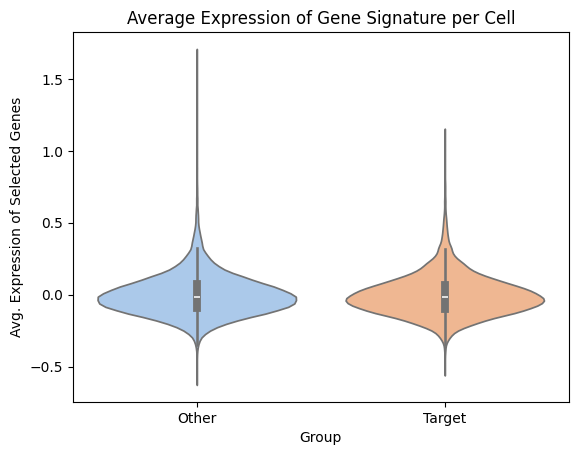

In [22]:
#plot a violin plot comparing the expression of HES2 pathway genes for "target" and "other" cells
sns.violinplot(data=adata.obs, x='mut', y='gene_signature_avg', inner='box', palette='pastel')
plt.title('Average Expression of Gene Signature per Cell')
plt.ylabel('Avg. Expression of Selected Genes')
plt.xlabel('Group')
plt.show()

In [23]:
#it can be hard to visualize this many cells as a boxplot, so let's calculate the means, medians, stdev
target_expr = adata.obs.loc[adata.obs['mut'] == 'Target', 'gene_signature_avg']
other_expr = adata.obs.loc[adata.obs['mut'] == 'Other', 'gene_signature_avg']

print("Means:", target_expr.mean(), other_expr.mean())
print("Medians:", target_expr.median(), other_expr.median())
print("Std Devs:", target_expr.std(), other_expr.std())

Means: -0.0039197730891660015 -0.0014438111323767792
Medians: -0.01874344241363636 -0.015770224515151518
Std Devs: 0.14180598890980242 0.14300981551195183


In [24]:
#and see if the distributions are statistically different
group_1 = adata.obs[adata.obs['mut'] == 'Target']['gene_signature_avg']
group_2 = adata.obs[adata.obs['mut'] == 'Other']['gene_signature_avg']

stat, pval = ranksums(group_1.dropna(), group_2.dropna())
print(f'Wilcoxon p-value: {pval}')

Wilcoxon p-value: 0.02176332274702278


In [25]:
#let's plot the differences in mean expression for "target" and "other" cells 
#we will look at genes in the HES2 pathway, and genes not in the pathway separately

#split the original object into "target" and "other" subobjects
#we did this earlier, but redoing it now that we have calculated the gene expression means
adata_target = adata.obs['mut'] == 'Target'
adata_other = adata.obs['mut'] == 'Other'

#define full gene sets
all_genes = adata.var_names.tolist()
not_gene_list = list(set(all_genes) - set(gene_list))

#make a function that gives average expression for each of our lists
def avg_expr(genes, cells):
    X = adata[cells, genes].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()
    return X.mean()

#create an empty list to "store" our mean values into
data = []

#calculate the means using our function above and add it to the data list
for group_name, mask in [('Target', adata_target), ('Other', adata_other)]:
    # In gene list
    mean_in_list = avg_expr(gene_list, mask)
    # Not in gene list
    mean_not_in_list = avg_expr(not_gene_list, mask)

    data.append({'Group': group_name, 'Subset': 'In gene list', 'Mean': mean_in_list})
    data.append({'Group': group_name, 'Subset': 'Not in gene list', 'Mean': mean_not_in_list})

#create a dataframe from the data list
df = pd.DataFrame(data)

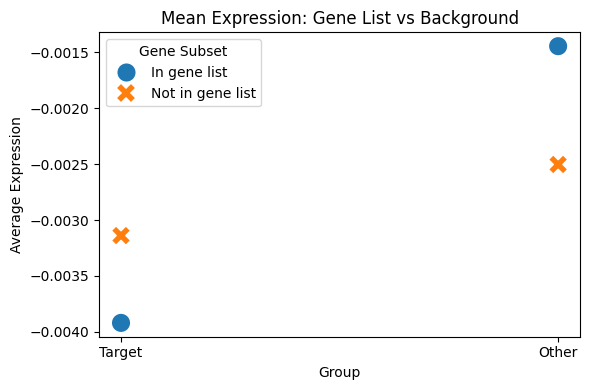

In [26]:
#plot all the means
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Group', y='Mean', hue='Subset', s=200, style='Subset')
plt.title('Mean Expression: Gene List vs Background')
plt.ylabel('Average Expression')
plt.legend(title='Gene Subset')
plt.tight_layout()
plt.show()

#here we see that the expression for genes not in the gene list is similar
#but for genes in the gene set it is different
#this is good because it shows our mutations affects the HES2 pathway specifically

In [27]:
#making a volcano plot

#use scanpy's built in function to calculate differential gene values
sc.tl.rank_genes_groups(adata, groupby='mut', method='wilcoxon', 
                        groups=['Target'], reference='Other')

/nas/longleaf/home/kritis/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [28]:
#extract this info as a dataframe
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
de_genes = pd.DataFrame(
    {group + '_' + key: result[key][group]
     for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']}
)

#look at the data
de_genes

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj
0,HIST2H2BE,7.368357,NaN,3.020538e-11
1,RASSF10,7.282773,NaN,4.523190e-11
2,LDLRAD4,7.280499,-1.602722,4.523190e-11
3,HHIP-AS1,6.848704,NaN,8.292260e-10
4,ITGA11,6.609318,-1.747571,3.938175e-09
...,...,...,...,...
1219,FDXR,-8.615104,NaN,1.710622e-15
1220,ALDH3A1,-10.908886,NaN,3.198605e-25
1221,CDKN1A,-11.332732,NaN,3.685933e-27
1222,PHLDA3,-11.410033,NaN,2.280222e-27


In [29]:
#making the violin plot

#set a threshold for logfold change and p valyue
fc_thresh = 1
pval_thresh = 0.05

#create -log10(padj) column
de_genes['neg_log10_padj'] = -np.log10(de_genes['Target_pvals_adj'])

#label significance
de_genes['significant'] = 'Not Sig'
de_genes.loc[(de_genes['Target_pvals_adj'] < pval_thresh) & (de_genes['Target_logfoldchanges'] > fc_thresh), 'significant'] = 'Up'
de_genes.loc[(de_genes['Target_pvals_adj'] < pval_thresh) & (de_genes['Target_logfoldchanges'] < -fc_thresh), 'significant'] = 'Down'

#look at the df
de_genes

,Target_names,Target_scores,Target_logfoldchanges,Target_pvals_adj,neg_log10_padj,significant
0,HIST2H2BE,7.368357,NaN,3.020538e-11,10.519916,Not Sig
1,RASSF10,7.282773,NaN,4.523190e-11,10.344555,Not Sig
2,LDLRAD4,7.280499,-1.602722,4.523190e-11,10.344555,Down
3,HHIP-AS1,6.848704,NaN,8.292260e-10,9.081327,Not Sig
4,ITGA11,6.609318,-1.747571,3.938175e-09,8.404705,Down
...,...,...,...,...,...,...
1219,FDXR,-8.615104,NaN,1.710622e-15,14.766846,Not Sig
1220,ALDH3A1,-10.908886,NaN,3.198605e-25,24.495039,Not Sig
1221,CDKN1A,-11.332732,NaN,3.685933e-27,26.433453,Not Sig
1222,PHLDA3,-11.410033,NaN,2.280222e-27,26.642023,Not Sig


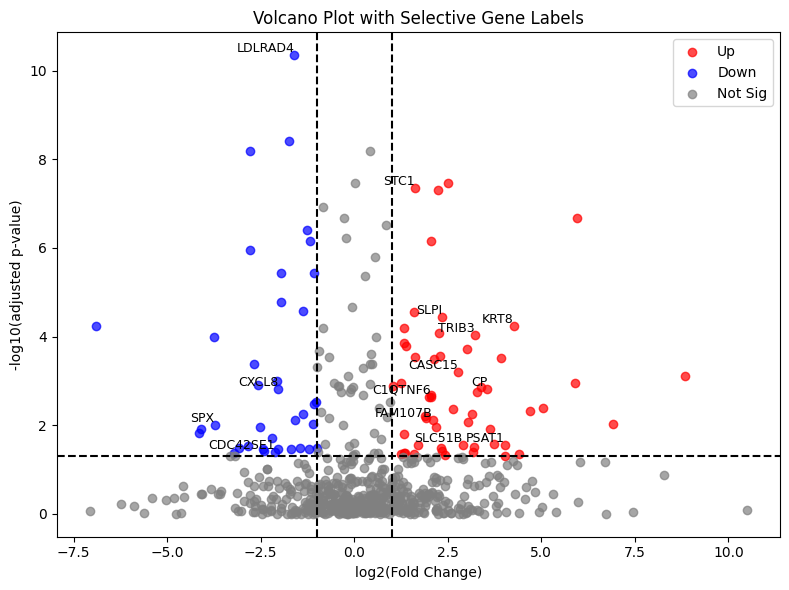

In [30]:
#plot

#set parameters
plt.figure(figsize=(8, 6))
colors = {'Up': 'red', 'Down': 'blue', 'Not Sig': 'gray'}

#add color labels for different levels of significance
for sig, color in colors.items():
    subset = de_genes[de_genes['significant'] == sig]
    plt.scatter(subset['Target_logfoldchanges'], subset['neg_log10_padj'], c=color, label=sig, alpha=0.7)

#filter genes to label: in list AND pass thresholds
label_de_genes = de_genes[
    (de_genes['Target_names'].isin(gene_list)) &
    (de_genes['Target_pvals_adj'] < pval_thresh) &
    (abs(de_genes['Target_logfoldchanges']) > fc_thresh)
]

#add labels
for _, row in label_de_genes.iterrows():
    plt.text(row['Target_logfoldchanges'], row['neg_log10_padj'], row['Target_names'],
             fontsize=9, ha='right', va='bottom', color='black')

#threshold lines
plt.axhline(-np.log10(pval_thresh), color='black', linestyle='--')
plt.axvline(fc_thresh, color='black', linestyle='--')
plt.axvline(-fc_thresh, color='black', linestyle='--')

#adding details to plot
plt.xlabel("log2(Fold Change)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano Plot with Selective Gene Labels")
plt.legend()
plt.tight_layout()
plt.show()